In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
# ══════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════

# Data
IMG_SIZE         = 96
BATCH_SIZE       = 64
CLASSES          = ['surprise', 'happy', 'sad']
NUM_CLASSES      = len(CLASSES)
DATA_DIR         = 'emotion_dataset/'
MODEL_DIR        = 'generated_mobilenet/'

# Architecture
ALPHA            = 0.5          # MobileNetV2 width multiplier for ESP32

# Phase 1 — train head only
EPOCHS           = 25
INITIAL_LR       = 5e-4
MIN_LR           = 1e-7

# Phase 2 — fine-tune top layers
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LR     = 5e-5
FINE_TUNE_AT     = 90

# Regularization
DROPOUT_RATE     = 0.2
WEIGHT_DECAY     = 5e-5

os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Training {NUM_CLASSES} classes: {CLASSES}')
print(f'Input size: {IMG_SIZE}x{IMG_SIZE}')
print(f'MobileNetV2 α={ALPHA}')

Training 3 classes: ['surprise', 'happy', 'sad']
Input size: 96x96
MobileNetV2 α=0.5


In [4]:
# ══════════════════════════════════════════════════════════════
# Data Loading
# ══════════════════════════════════════════════════════════════

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_names=CLASSES,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_names=CLASSES,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_names=CLASSES,
    shuffle=False,
)

# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print(f'Training batches: {len(train_ds)}')
print(f'Validation batches: {len(val_ds)}')
print(f'Test batches: {len(test_ds)}')

Found 12600 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Training batches: 197
Validation batches: 15
Test batches: 15


In [5]:
# ══════════════════════════════════════════════════════════════
# Model — MobileNetV2 + custom head (Phase 1: head only)
# ══════════════════════════════════════════════════════════════

def build_model(input_shape, num_classes, alpha, dropout_rate):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=alpha,
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs), base_model

model, base_model = build_model((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES, ALPHA, DROPOUT_RATE)
model.summary()
print(f'\nBase model layers: {len(base_model.layers)}')
print(f'Fine-tune will unfreeze from layer {FINE_TUNE_AT} onwards')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.50_96             │ (None, 3, 3, 1280)     │       706,224 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 876,211 (3.34 MB)

 Trainable params: 167,171 (653.01 KB)

 Non-trainable params: 709,040 (2.70 MB)


Base model layers: 154
Fine-tune will unfreeze from layer 90 onwards


In [6]:
# ══════════════════════════════════════════════════════════════
# Training with Cosine Decay LR Schedule
# ══════════════════════════════════════════════════════════════
# Using cosine decay instead of ReduceLROnPlateau for smoother training

# Cosine decay schedule
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=EPOCHS * len(train_ds),
    alpha=MIN_LR / INITIAL_LR,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, 'best_model.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=0,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/25


197/197 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.5137 - loss: 1.1237 - val_accuracy: 0.5733 - val_loss: 0.9092
Epoch 2/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5867 - loss: 0.9256 - val_accuracy: 0.5922 - val_loss: 0.8978
Epoch 3/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6083 - loss: 0.8842 - val_accuracy: 0.6033 - val_loss: 0.8897
Epoch 4/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.6153 - loss: 0.8582 - val_accuracy: 0.6078 - val_loss: 0.8828
Epoch 5/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6201 - loss: 0.8438 - val_accuracy: 0.6156 - val_loss: 0.8802
Epoch 6/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6153 - loss: 0.8398 - val_accuracy: 0.6078 - val_loss: 0.8762
Epoch 7/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6225 - loss: 0.8324 - val_accuracy: 0.6100 - val_loss: 0.8737
Epoch 8/25
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.6284 - loss: 0.8210 - val_accuracy: 0.60

In [7]:
# ══════════════════════════════════════════════════════════════
# Phase 2 — Fine-tune top layers of MobileNetV2
# ══════════════════════════════════════════════════════════════

# Unfreeze the base model
base_model.trainable = True

# Re-freeze everything below FINE_TUNE_AT
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Keep all BatchNorm layers frozen — critical for small datasets
# to preserve the pretrained running statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreeze: {trainable_count} / {len(base_model.layers)}')

# Lower LR cosine decay for fine-tuning
ft_lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=FINE_TUNE_LR,
    decay_steps=FINE_TUNE_EPOCHS * len(train_ds),
    alpha=1e-7 / FINE_TUNE_LR,
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=ft_lr_schedule,
        weight_decay=WEIGHT_DECAY,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'],
)

ft_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, 'best_model_finetuned.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=0,
    ),
]

print('\n--- Phase 2: Fine-tuning ---')
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=ft_callbacks,
    verbose=1,
)

Trainable base layers after unfreeze: 42 / 154

--- Phase 2: Fine-tuning ---
Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step - accuracy: 0.6496 - loss: 0.7922 - val_accuracy: 0.6444 - val_loss: 0.8099
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - accuracy: 0.7069 - loss: 0.6892 - val_accuracy: 0.6711 - val_loss: 0.7767
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 29s 147ms/step - accuracy: 0.7398 - loss: 0.6144 - val_accuracy: 0.6367 - val_loss: 0.8031
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 30s 153ms/step - accuracy: 0.7706 - loss: 0.5560 - val_accuracy: 0.6956 - val_loss: 0.7396
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 29s 148ms/step - accuracy: 0.7968 - loss: 0.5075 - val_accuracy: 0.6878 - val_loss: 0.7556
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.8179 - loss: 0.4589 - val_accuracy: 0.6833 - val_loss: 0.7480
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.8363 - loss: 0.4175 - val_accuracy: 0.6800 - val_loss: 0.7762
Epoch 

In [8]:
# ══════════════════════════════════════════════════════════════
# Evaluation
# ══════════════════════════════════════════════════════════════

print('\n' + '='*70)
print('Test Set Evaluation')
print('='*70)

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

# Get predictions
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print('\nPer-Class Performance:')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


Test Set Evaluation
Test Loss: 0.8506
Test Accuracy: 0.6800

Per-Class Performance:
              precision    recall  f1-score   support

    surprise     0.6824    0.6733    0.6779       300
       happy     0.7266    0.7000    0.7131       300
         sad     0.6349    0.6667    0.6504       300

    accuracy                         0.6800       900
   macro avg     0.6813    0.6800    0.6804       900
weighted avg     0.6813    0.6800    0.6804       900



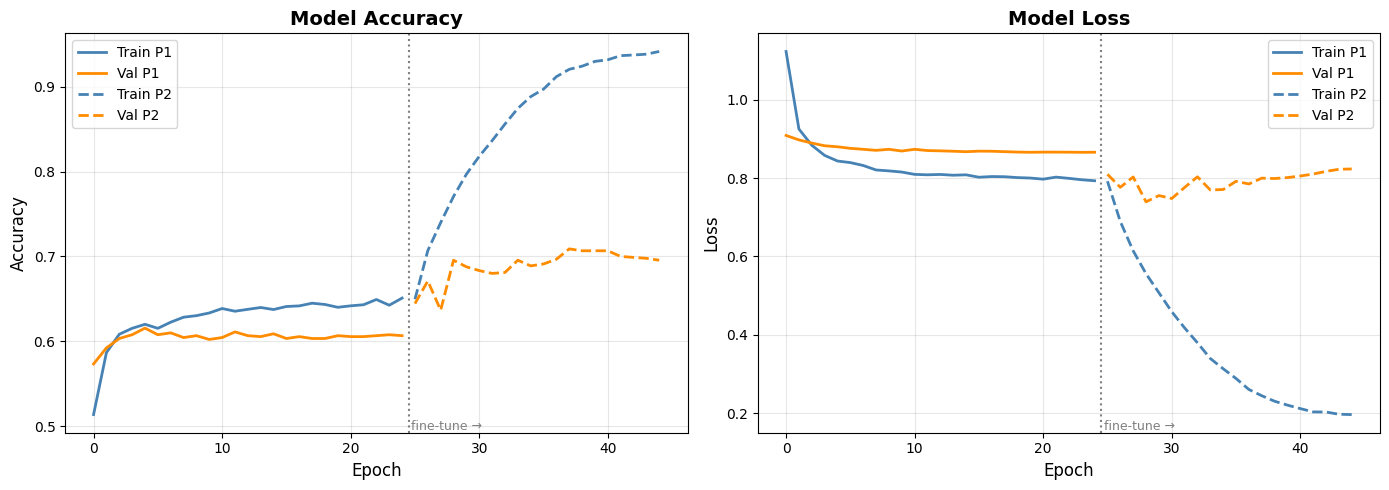

Phase 1: 25 epochs  |  Phase 2: 20 epochs
Best val accuracy — P1: 0.6156  P2: 0.7089


In [9]:
# ══════════════════════════════════════════════════════════════
# Training Curves — Phase 1 (head) + Phase 2 (fine-tune)
# ══════════════════════════════════════════════════════════════

n1 = len(history.history['accuracy'])
n2 = len(history_ft.history['accuracy'])
epochs_p1 = range(n1)
epochs_p2 = range(n1, n1 + n2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, ylabel in zip(
    axes,
    ['accuracy', 'loss'],
    ['Model Accuracy', 'Model Loss'],
    ['Accuracy', 'Loss'],
):
    # Phase 1
    ax.plot(epochs_p1, history.history[metric],
            color='steelblue', linewidth=2, label='Train P1')
    ax.plot(epochs_p1, history.history[f'val_{metric}'],
            color='darkorange', linewidth=2, label='Val P1')
    # Phase 2
    ax.plot(epochs_p2, history_ft.history[metric],
            color='steelblue', linewidth=2, linestyle='--', label='Train P2')
    ax.plot(epochs_p2, history_ft.history[f'val_{metric}'],
            color='darkorange', linewidth=2, linestyle='--', label='Val P2')
    # Phase boundary
    ax.axvline(x=n1 - 0.5, color='gray', linestyle=':', linewidth=1.5)
    ax.text(n1 - 0.3, ax.get_ylim()[0], 'fine-tune →',
            fontsize=9, color='gray', va='bottom')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Phase 1: {n1} epochs  |  Phase 2: {n2} epochs')
print(f'Best val accuracy — P1: {max(history.history["val_accuracy"]):.4f}  '
      f'P2: {max(history_ft.history["val_accuracy"]):.4f}')

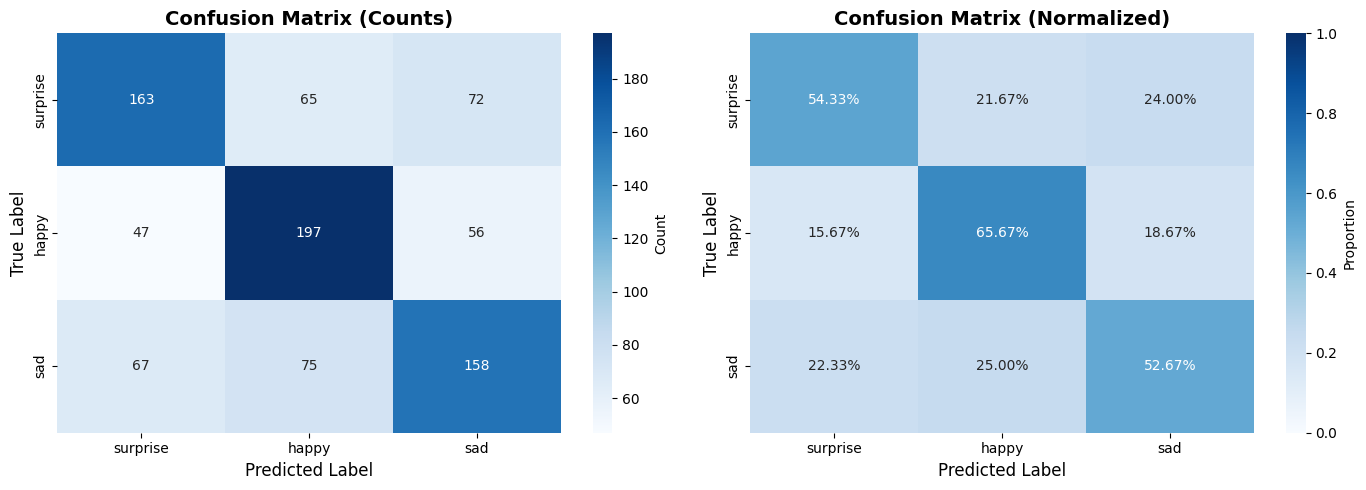

surprise: 54.3%
happy: 65.7%
sad: 52.7%


In [13]:
# ══════════════════════════════════════════════════════════════
# Confusion Matrix
# ══════════════════════════════════════════════════════════════

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES, 
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
for i, cls in enumerate(CLASSES):
    acc = cm[i, i] / cm[i].sum()
    print(f'{cls}: {acc:.1%}')